In [1]:
import sys
from pathlib import Path
notebook_dir = Path().resolve()
ROOT = notebook_dir.parent
sys.path.append(str(ROOT))


from src.plotting import display_result_tables,plot_accs_bar_with_singe_embs,plot_loss_vs_acc_per_encoder,intra_inter_similarities_sampled,plot_intra_inter,plot_avgAcc_vs_singe_embs, plot_loss_per_encoder
import torch
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='~/datasets/Cora', name='Cora')
data = dataset[0]


all_losses=torch.load(Path("/Users/emely/Uni/Thesis/Thesis/cora/results/loss_histories.pt"))
other_accs=torch.load(Path("/Users/emely/Uni/Thesis/Thesis/cora/results/best_acc_node_pos.pt"))
all_embeddings = torch.load(Path("/Users/emely/Uni/Thesis/Thesis/cora/results/embeddings.pt"))
accs = torch.load(Path("/Users/emely/Uni/Thesis/Thesis/cora/results/best_accs.pt"))
svm_results = torch.load(Path("/Users/emely/Uni/Thesis/Thesis/cora/results/svm_results.pt"))
svm_results_node_pos = torch.load(Path("/Users/emely/Uni/Thesis/Thesis/cora/results/svm_results_node_pos.pt"))

encoders = ['gcn', 'sage', 'gat', 'gin']
modes= ['Rand-Rewire', 'Rand-Aug', 'DP-Rewire', 'DP-Aug']

In [2]:
display_result_tables(accs, svm_results, other_accs, svm_results_node_pos)


## MLP Results

,Mode,gcn,sage,gat,gin
0,Rand-Rewire,0.768 ± 0.021,0.591 ± 0.021,0.795 ± 0.011,0.736 ± 0.016
1,Rand-Aug,0.816 ± 0.019,0.804 ± 0.012,0.818 ± 0.011,0.779 ± 0.011
2,DP-Rewire,0.794 ± 0.009,0.584 ± 0.016,0.791 ± 0.008,0.759 ± 0.009
3,DP-Aug,0.820 ± 0.008,0.763 ± 0.007,0.813 ± 0.008,0.776 ± 0.014


## SVM Results

,Mode,gcn,sage,gat,gin
0,Rand-Rewire,0.768 ± 0.018,0.586 ± 0.014,0.787 ± 0.011,0.738 ± 0.019
1,Rand-Aug,0.820 ± 0.015,0.803 ± 0.009,0.819 ± 0.008,0.772 ± 0.001
2,DP-Rewire,0.790 ± 0.013,0.586 ± 0.021,0.799 ± 0.010,0.766 ± 0.009
3,DP-Aug,0.812 ± 0.024,0.758 ± 0.011,0.818 ± 0.010,0.788 ± 0.007


## Node2Vec & PosEnc & Original Features – MLP + SVM

,Embedding,MLP Test Accuracy,SVM Test Accuracy
0,LaplacianPosEnc,0.571,0.600
1,Node2Vec,0.719,0.699
2,OriginalFeatures,0.561,0.600


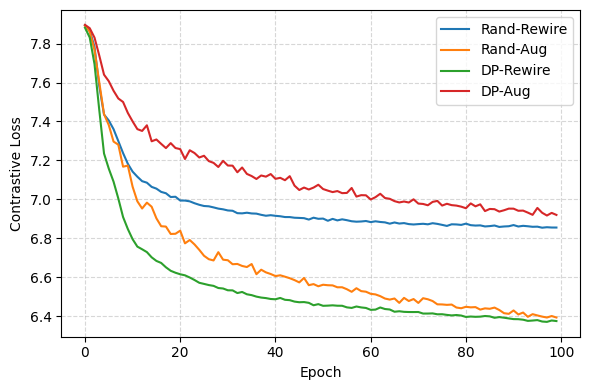

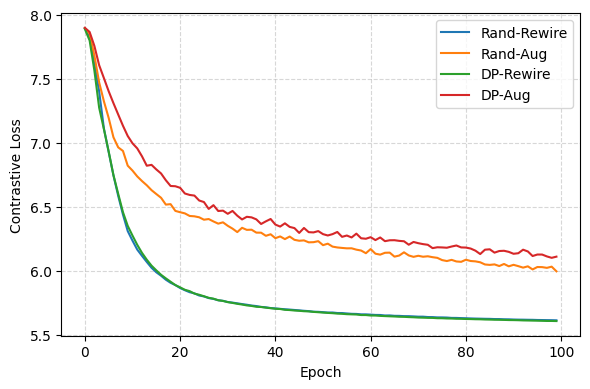

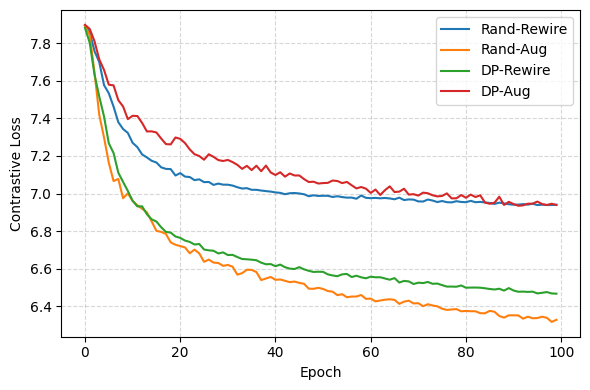

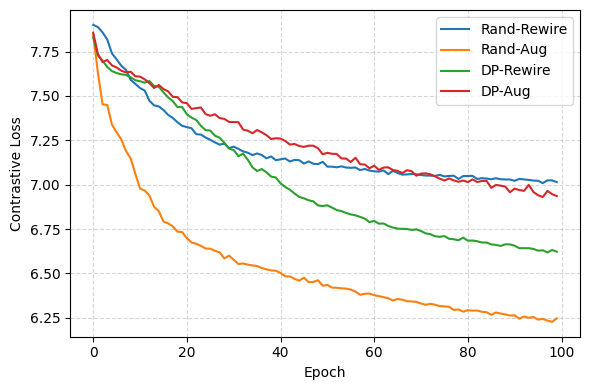

In [3]:
plot_loss_per_encoder(all_losses)

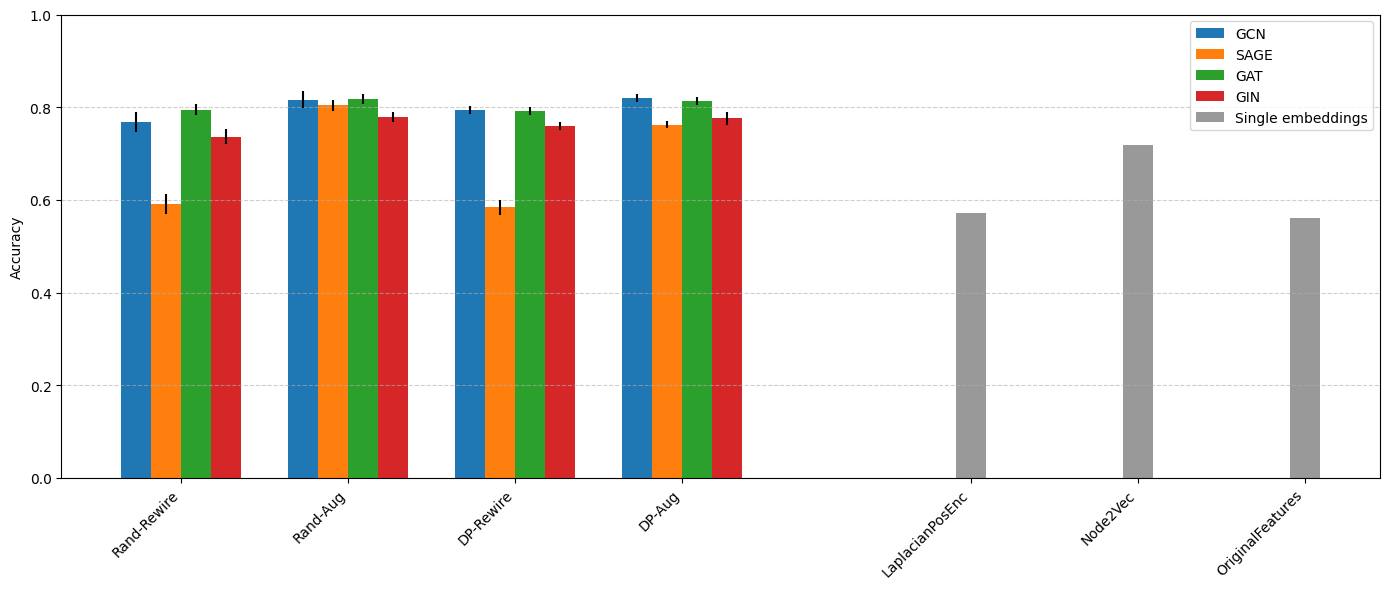

In [4]:
plot_accs_bar_with_singe_embs(other_accs,modes,encoders,accs)

   

/Users/emely/Uni/Thesis/Thesis/src/plotting.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_curve = torch.tensor(all_losses[mode][enc])


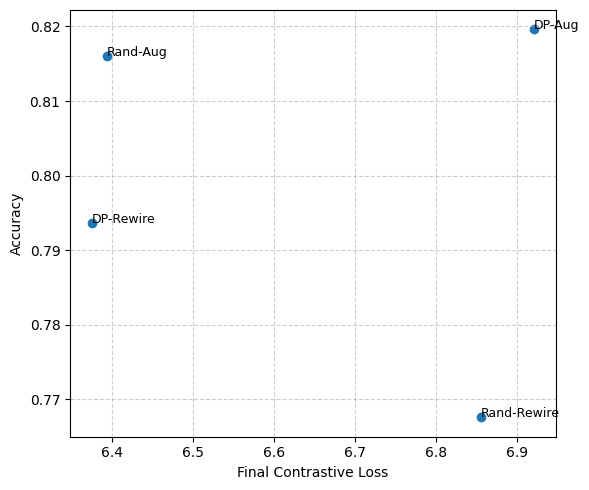

/Users/emely/Uni/Thesis/Thesis/src/plotting.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_curve = torch.tensor(all_losses[mode][enc])


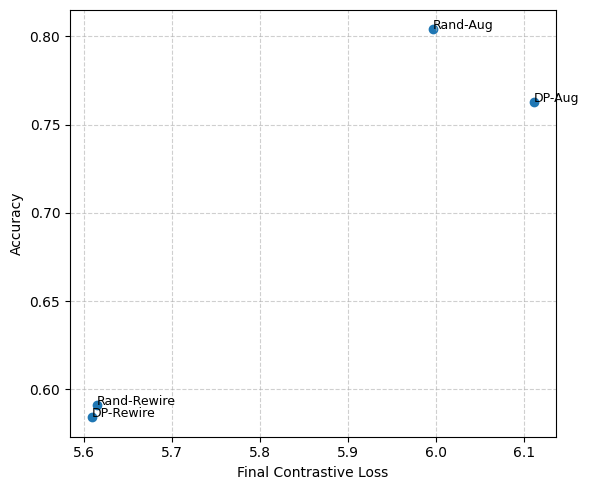

/Users/emely/Uni/Thesis/Thesis/src/plotting.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_curve = torch.tensor(all_losses[mode][enc])


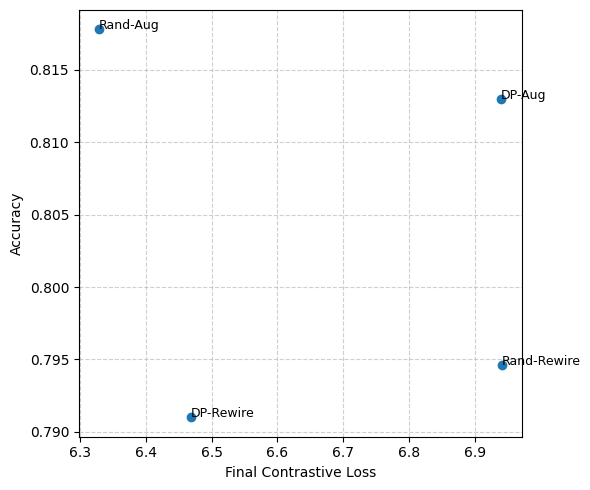

/Users/emely/Uni/Thesis/Thesis/src/plotting.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_curve = torch.tensor(all_losses[mode][enc])


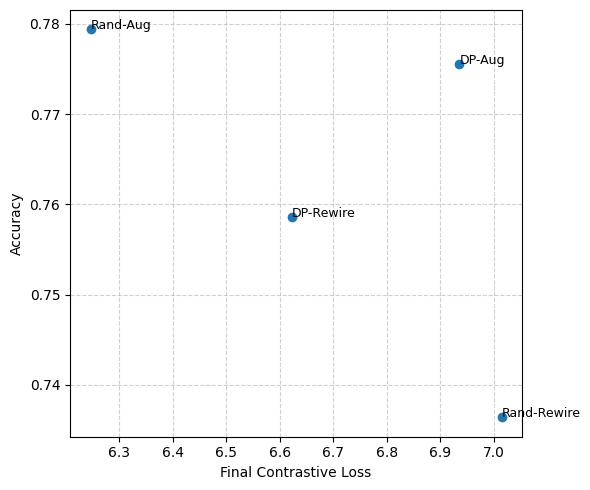

In [5]:
plot_loss_vs_acc_per_encoder(encoders,all_losses,accs)



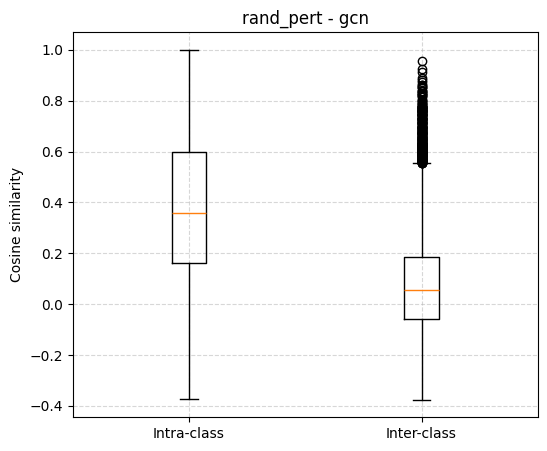

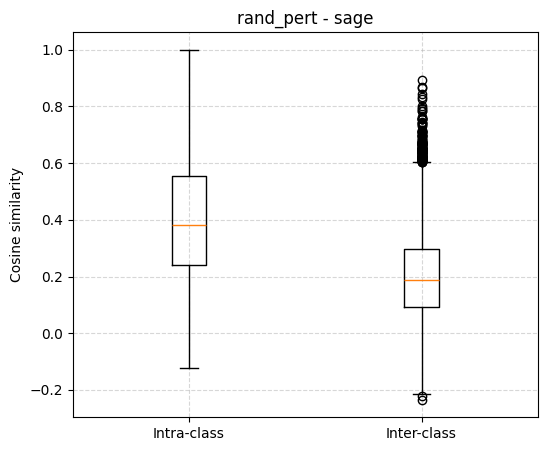

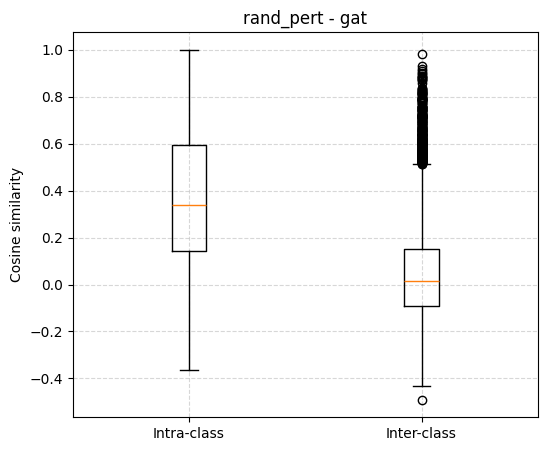

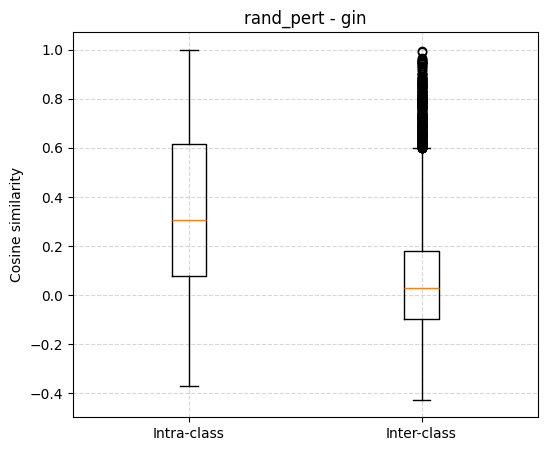

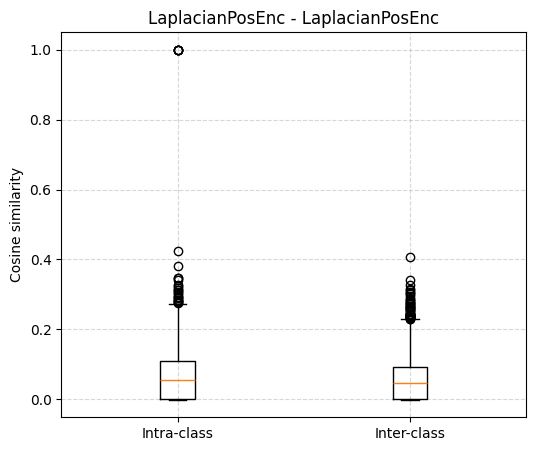

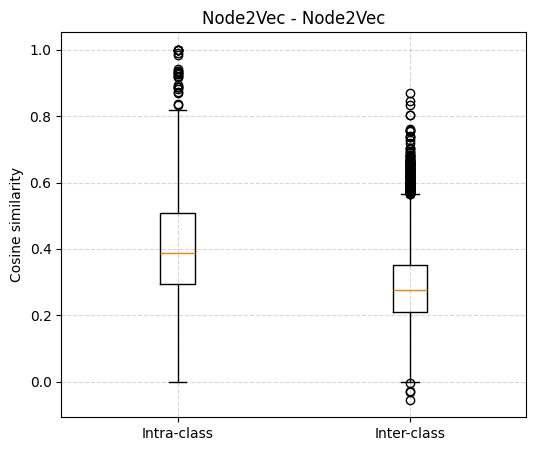

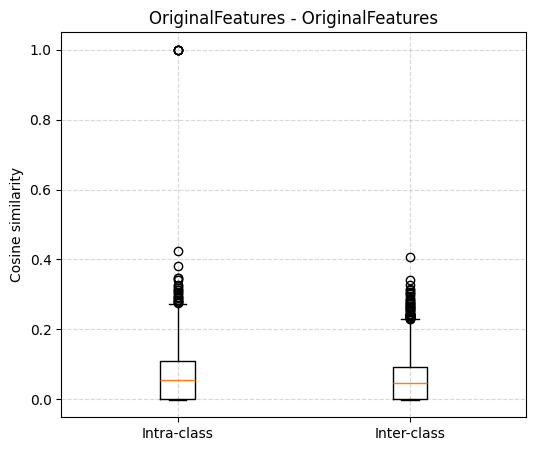

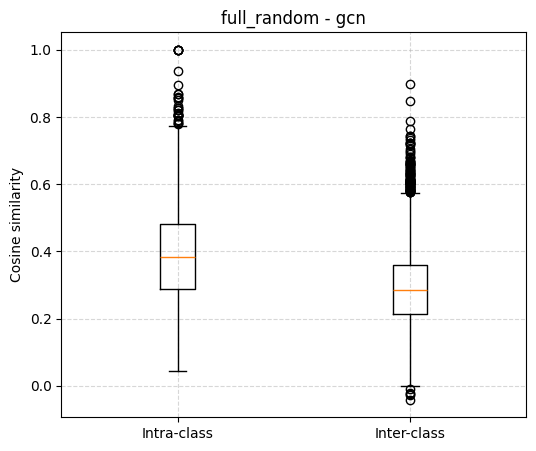

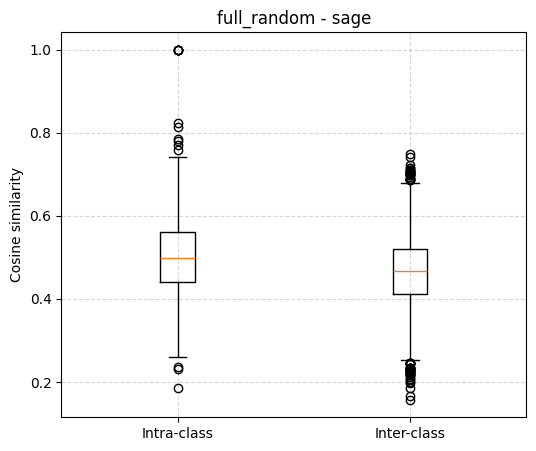

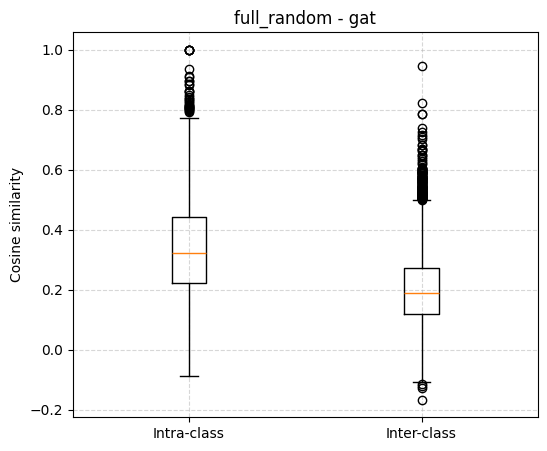

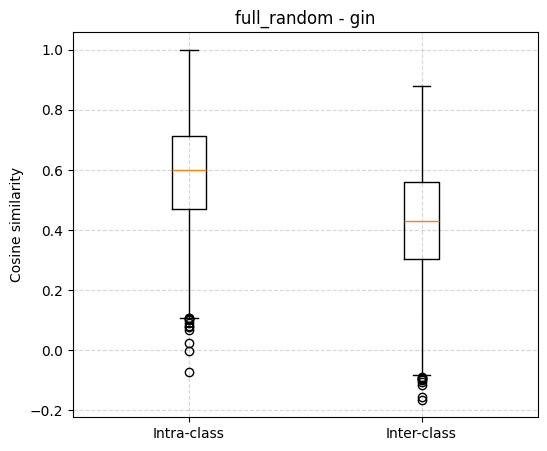

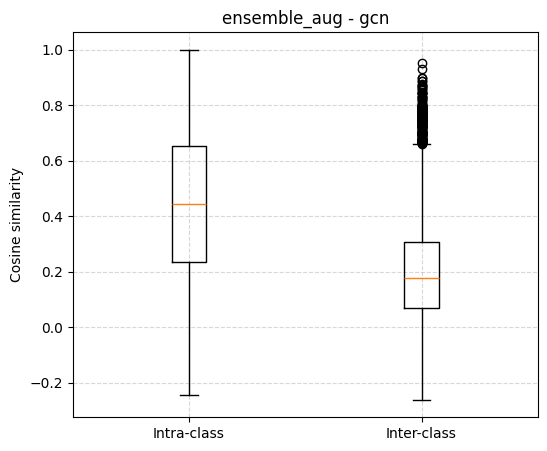

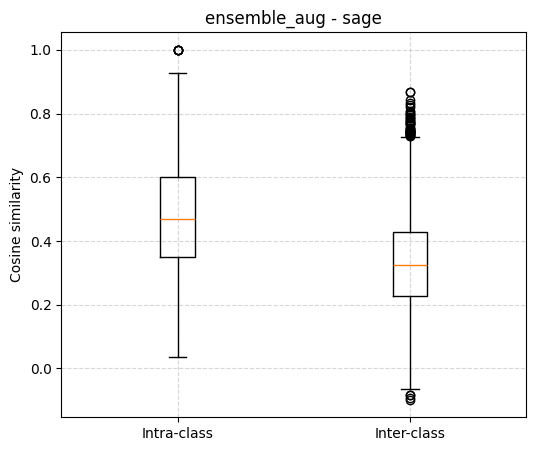

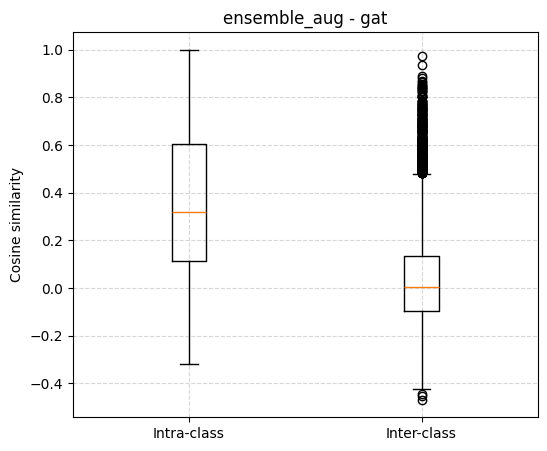

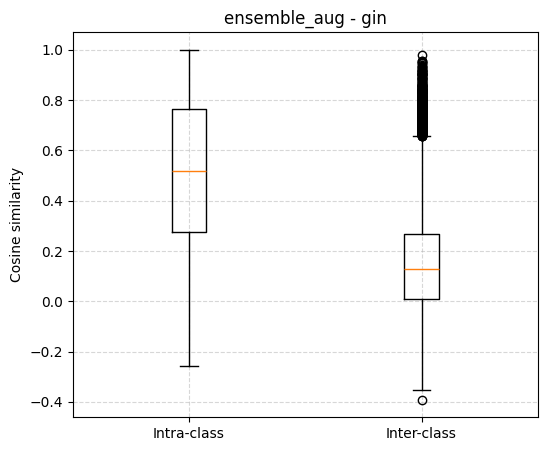

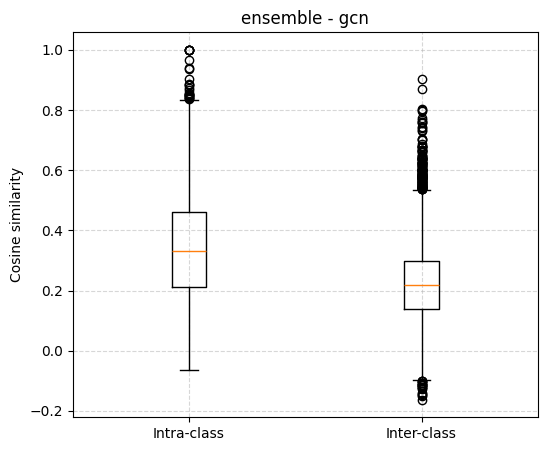

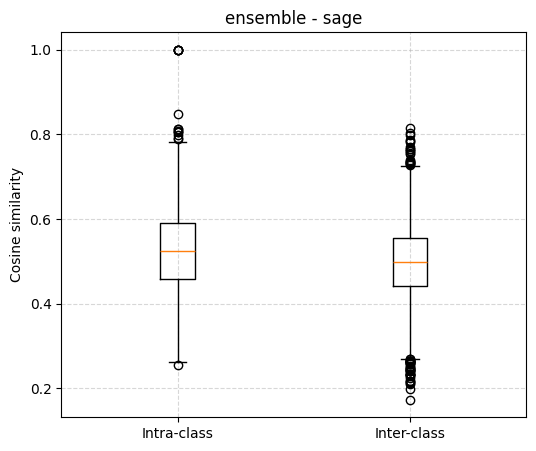

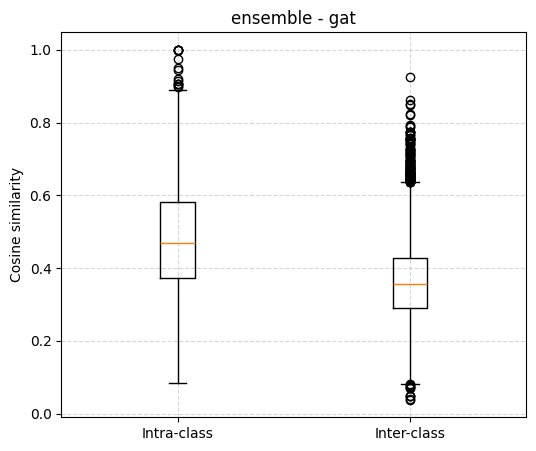

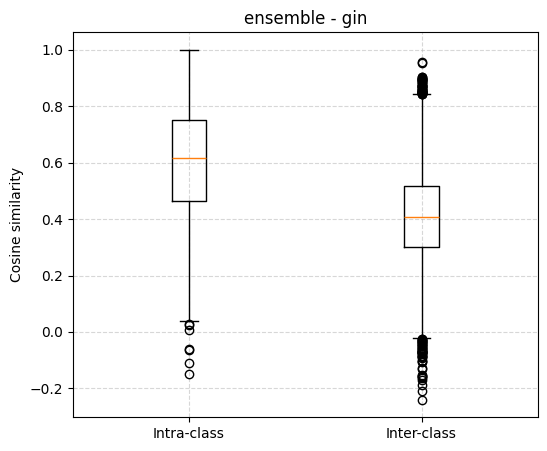

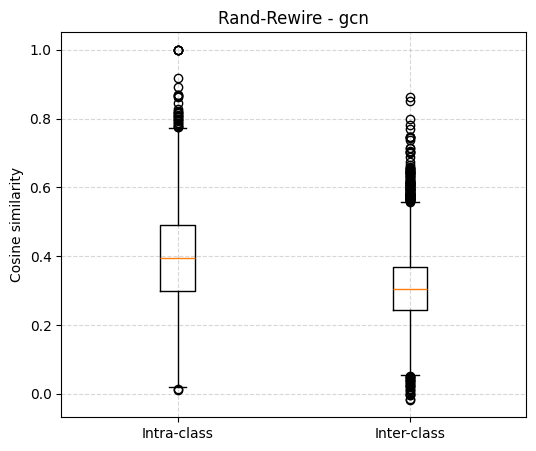

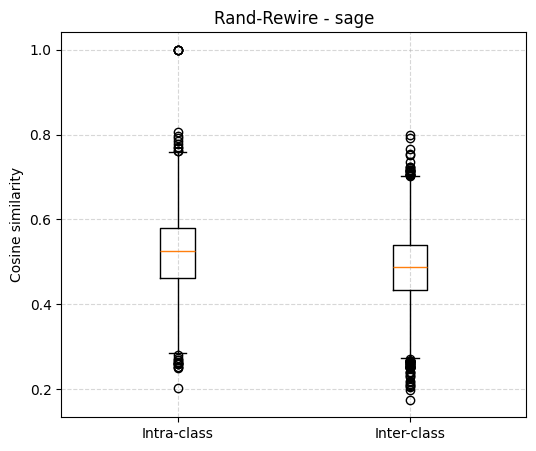

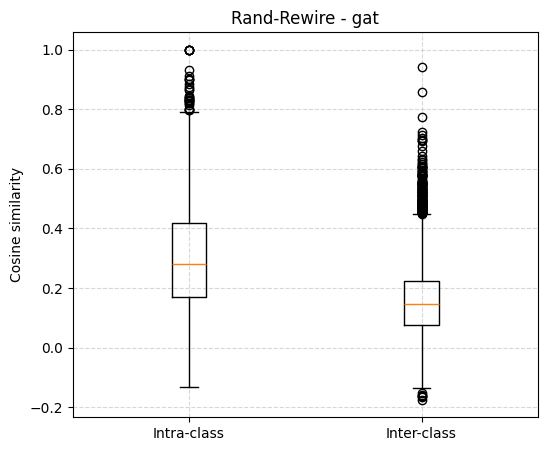

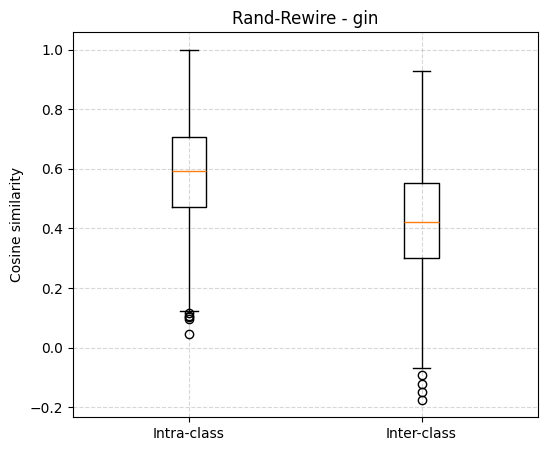

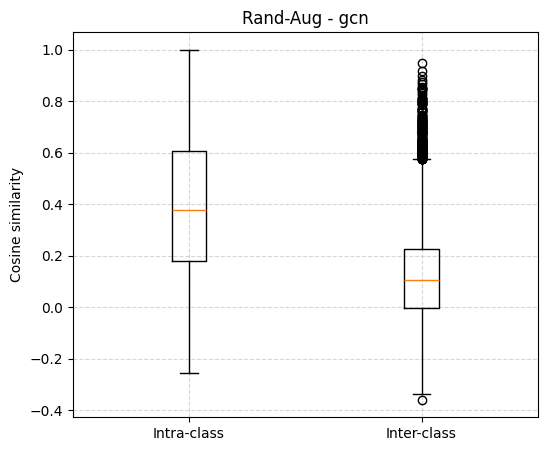

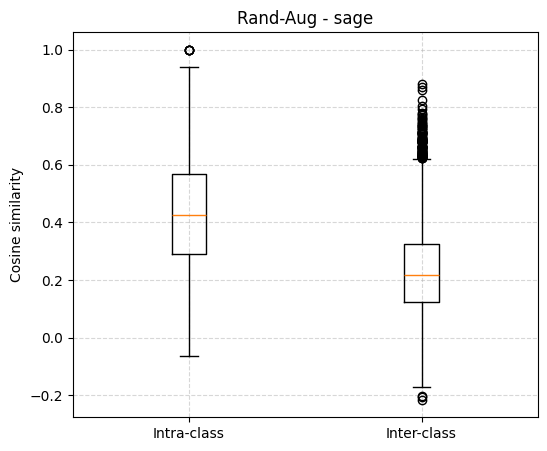

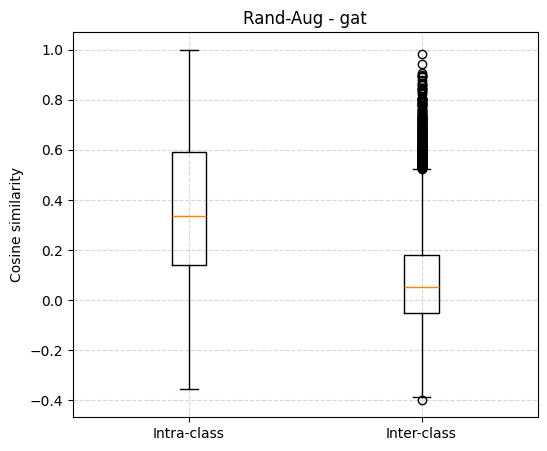

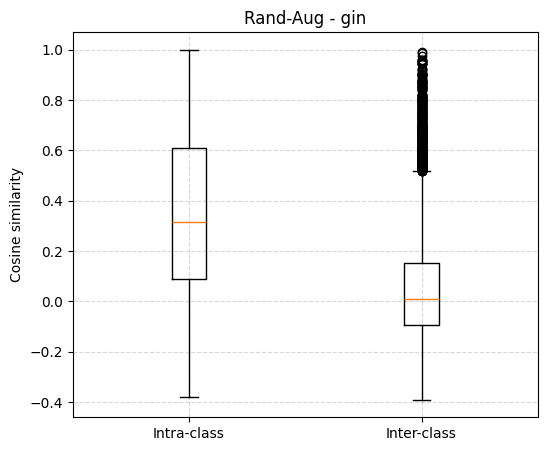

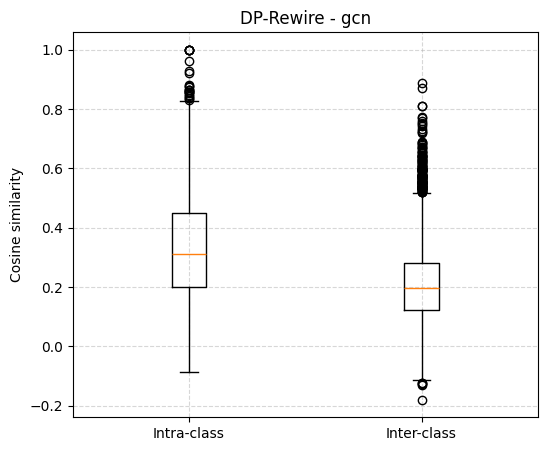

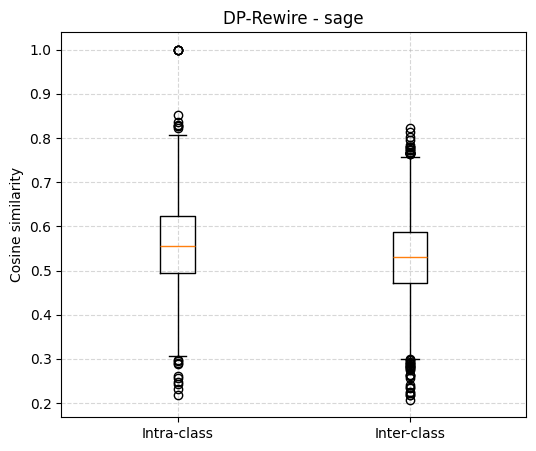

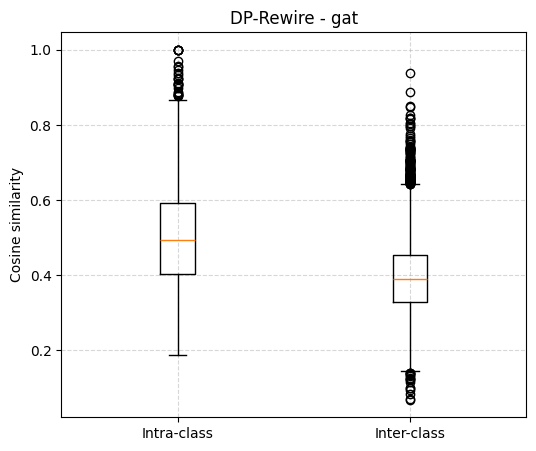

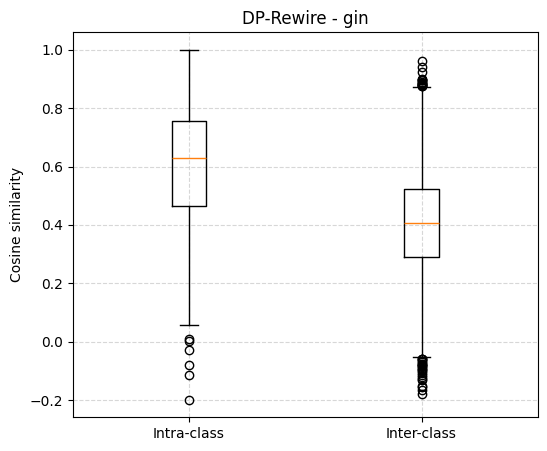

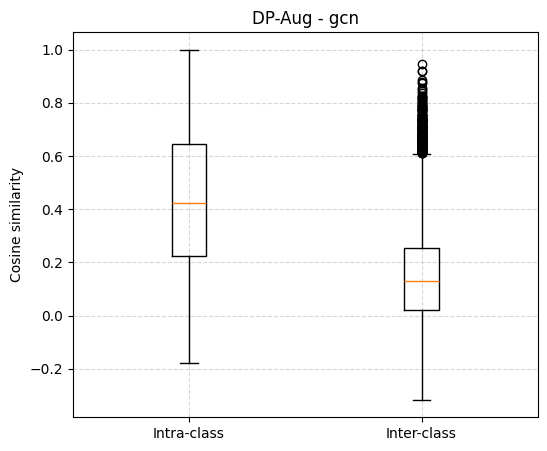

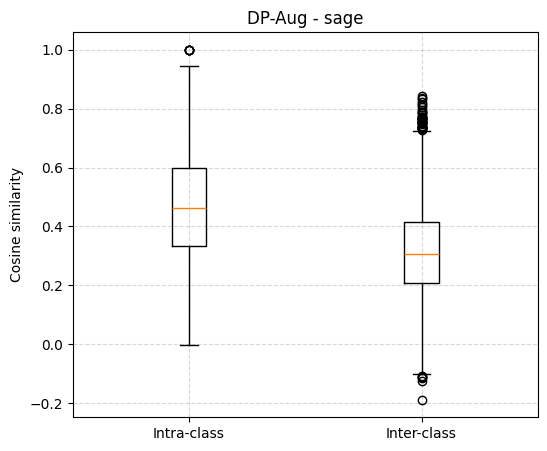

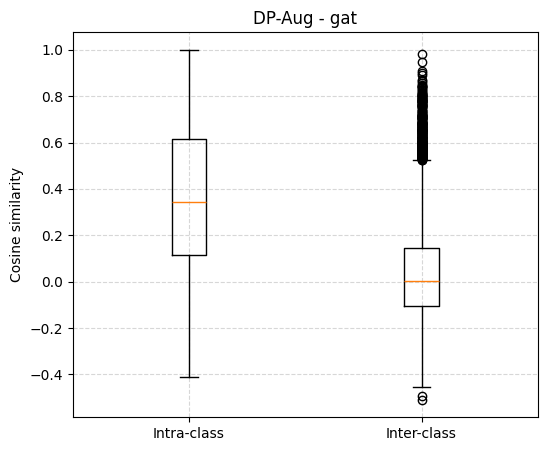

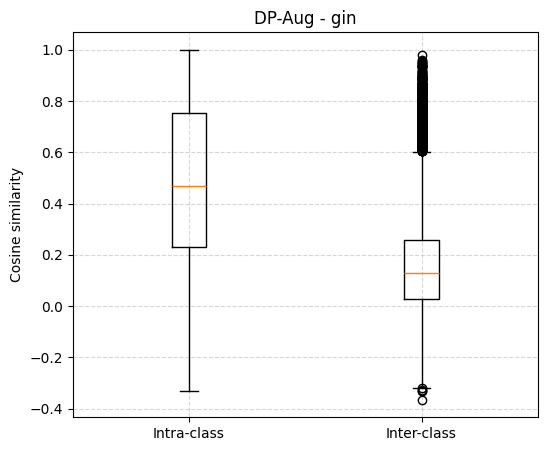

In [6]:
for mode_name, embeddings_per_encoder in all_embeddings.items():
    for encoder_name, emb in embeddings_per_encoder.items():
        intra, inter = intra_inter_similarities_sampled(emb, data.y, num_samples=10000)
        plot_intra_inter(intra, inter, f"{mode_name} - {encoder_name}")


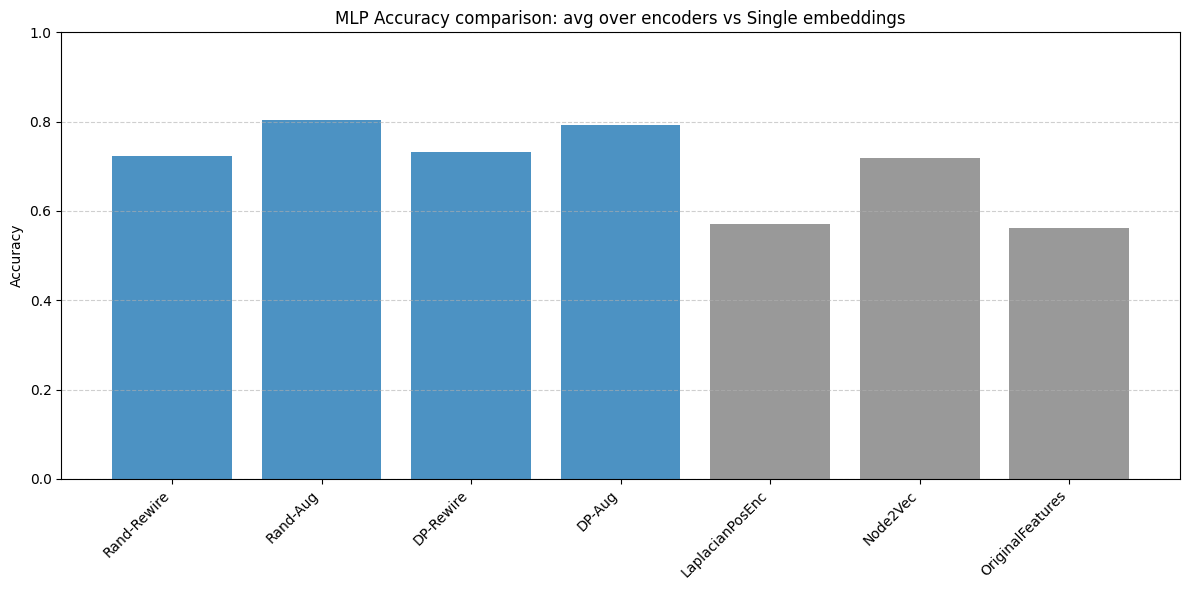

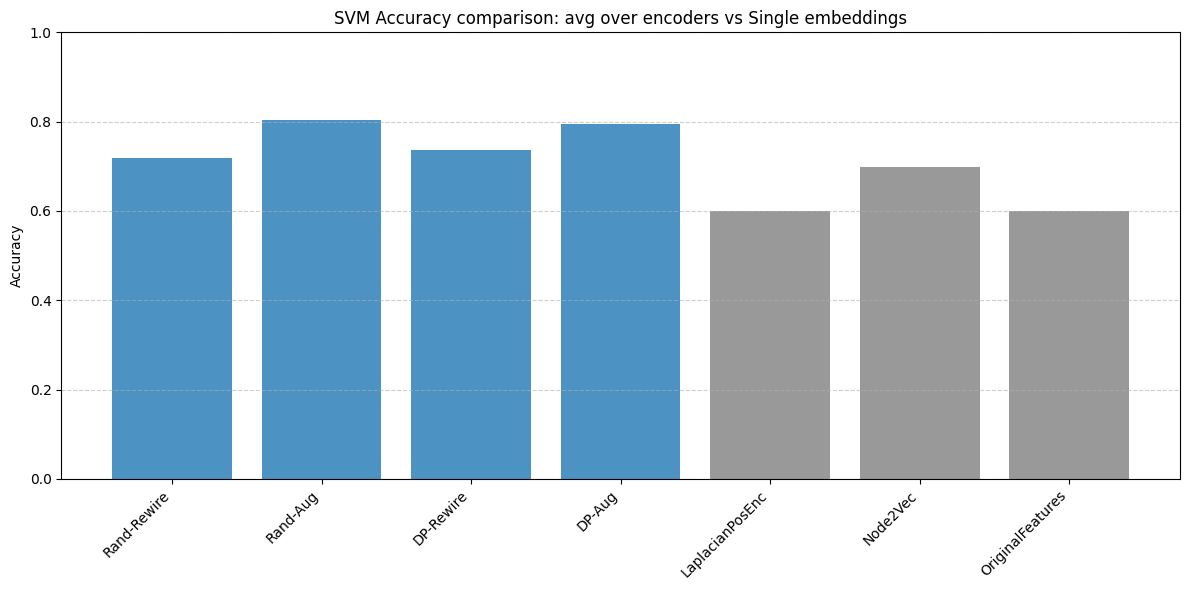

In [7]:
plot_avgAcc_vs_singe_embs(modes,other_accs,accs,"MLP Accuracy comparison: avg over encoders vs Single embeddings")
plot_avgAcc_vs_singe_embs(modes,svm_results_node_pos,svm_results,"SVM Accuracy comparison: avg over encoders vs Single embeddings")